In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# PCA Compression Analysis

Statistical analysis of PCA compression results across video frames and component levels (0–400 PCA components; 0 = original uncompressed).

Columns:
- `frame` — frame index
- `components` — number of PCA components used (0 = original/uncompressed)
- `mse` — mean squared error vs original
- `pca_size_bytes` — PCA-compressed size in bytes
- `encoded_size_bytes` — H.264-encoded size in bytes
- `raw_size_bytes` — raw (uncompressed) frame size in bytes
- `pict_type` — H.264 frame type (I, P, B)

In [4]:
# Load data
df = pd.read_csv('pca_compression_results.csv')

# Separate original (uncompressed) rows from compressed rows
# components == 0 marks the original uncompressed frame
ORIGINAL_COMPONENTS = 0

df_orig = df[df['components'] == ORIGINAL_COMPONENTS].copy()

# Fallback: treat rows where pca_size_bytes equals raw_size_bytes as uncompressed
if df_orig.empty:
    df_orig = df[df['pca_size_bytes'] == df['raw_size_bytes']].copy()

original_size = int(df_orig['raw_size_bytes'].iloc[0])

df_comp = df[df['components'] != ORIGINAL_COMPONENTS].copy()

# Add compression ratio column (relative to raw frame size)
df_comp['compression_ratio'] = original_size / df_comp['pca_size_bytes']
df_comp['size_reduction_pct'] = (1 - df_comp['pca_size_bytes'] / original_size) * 100

print(f"Total rows       : {len(df):,}")
print(f"Unique frames    : {df['frame'].nunique():,}")
print(f"Component levels : {sorted(df_comp['components'].unique())}")
print(f"Original size    : {original_size:,} bytes ({original_size/1024:.1f} KB)")
print(f"\nFirst few rows:")
df.head(10)

Total rows       : 18,887
Unique frames    : 1,111
Component levels : [np.int64(25), np.int64(50), np.int64(75), np.int64(100), np.int64(125), np.int64(150), np.int64(175), np.int64(200), np.int64(225), np.int64(250), np.int64(275), np.int64(300), np.int64(325), np.int64(350), np.int64(375), np.int64(400)]
Original size    : 150,528 bytes (147.0 KB)

First few rows:


,frame,components,mse,pca_size_bytes,encoded_size_bytes,raw_size_bytes,pict_type,explained_variance
0,0,400,146.251572,153836,313269,150528,I,0.999787
1,0,375,146.513944,144245,313269,150528,I,0.999630
2,0,350,147.066054,134654,313269,150528,I,0.999418
3,0,325,147.314078,125063,313269,150528,I,0.999135
4,0,300,147.564441,115472,313269,150528,I,0.998747
5,0,275,147.790050,105881,313269,150528,I,0.998215
6,0,250,148.145413,96290,313269,150528,I,0.997514
7,0,225,148.587928,86699,313269,150528,I,0.996595
8,0,200,149.536706,77108,313269,150528,I,0.995383
9,0,175,150.119811,67516,313269,150528,I,0.993823


## 1. Overall Descriptive Statistics

In [5]:
# Full dataset descriptive stats (compressed frames only — excludes the trivial zero-MSE originals)
print("=== Descriptive statistics (compressed frames only) ===")
desc = df_comp[['components', 'mse', 'pca_size_bytes', 'compression_ratio', 'size_reduction_pct']].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
)
desc.loc['cv'] = desc.loc['std'] / desc.loc['mean']   # coefficient of variation
desc

=== Descriptive statistics (compressed frames only) ===


,components,mse,pca_size_bytes,compression_ratio,size_reduction_pct
count,17776.000000,17776.000000,17776.000000,17776.000000,17776.000000
mean,212.500000,6.691629,81903.062500,3.256579,45.589483
std,115.247547,11.807556,44213.996188,3.521469,29.372606
min,25.000000,0.113607,9970.000000,0.978497,-2.197598
5%,25.000000,0.793388,9970.000000,0.978497,-2.197598
25%,118.750000,2.035760,45936.250000,1.278596,21.695797
50%,212.500000,4.111004,81903.500000,1.844192,45.589193
75%,306.250000,7.793830,117869.750000,3.307071,69.483252
95%,400.000000,17.259449,153836.000000,15.098094,93.376648
max,400.000000,192.016905,153836.000000,15.098094,93.376648


## 2. Size Statistics by Component Level

In [6]:
# Size is fully determined by (components × pixel_width) so it has zero variance per level.
# However the key statistics across levels show how the size budget changes.

size_stats = (
    df_comp.groupby('components')['pca_size_bytes']
    .agg(
        count='count',
        mean='mean',
        std='std',
        min='min',
        q25=lambda x: x.quantile(0.25),
        median='median',
        q75=lambda x: x.quantile(0.75),
        max='max',
    )
    .reset_index()
    .sort_values('components')
)

# Add KB column and compression ratio vs original for readability
size_stats['mean_KB'] = size_stats['mean'] / 1024
size_stats['compression_ratio'] = original_size / size_stats['mean']
size_stats['size_reduction_pct'] = (1 - size_stats['mean'] / original_size) * 100

print(f"Original (uncompressed) size: {original_size:,} bytes  ({original_size/1024:.1f} KB)\n")
print("Size statistics per PCA component level:")
display(size_stats[['components', 'mean_KB', 'compression_ratio', 'size_reduction_pct',
                     'min', 'q25', 'median', 'q75', 'max', 'std']].to_string(index=False, float_format='%.2f'))

Original (uncompressed) size: 150,528 bytes  (147.0 KB)

Size statistics per PCA component level:


' components  mean_KB  compression_ratio  size_reduction_pct    min       q25    median       q75    max  std\n         25     9.74              15.10               93.38   9970   9970.00   9970.00   9970.00   9970 0.00\n         50    19.10               7.70               87.01  19561  19561.00  19561.00  19561.00  19561 0.00\n         75    28.47               5.16               80.63  29152  29152.00  29152.00  29152.00  29152 0.00\n        100    37.83               3.89               74.26  38743  38743.00  38743.00  38743.00  38743 0.00\n        125    47.20               3.11               67.89  48334  48334.00  48334.00  48334.00  48334 0.00\n        150    56.57               2.60               61.52  57925  57925.00  57925.00  57925.00  57925 0.00\n        175    65.93               2.23               55.15  67516  67516.00  67516.00  67516.00  67516 0.00\n        200    75.30               1.95               48.77  77108  77108.00  77108.00  77108.00  77108 0.00\n        2

## 3. MSE Statistics by Component Level

In [7]:
# MSE varies across frames at each component level — this is the interesting distribution
mse_stats = (
    df_comp.groupby('components')['mse']
    .agg(
        count='count',
        mean='mean',
        std='std',
        cv=lambda x: x.std() / x.mean(),   # coefficient of variation
        min='min',
        q05=lambda x: x.quantile(0.05),
        q25=lambda x: x.quantile(0.25),
        median='median',
        q75=lambda x: x.quantile(0.75),
        q95=lambda x: x.quantile(0.95),
        max='max',
    )
    .reset_index()
    .sort_values('components')
)

print("MSE statistics per PCA component level (across all frames):\n")
display(mse_stats.set_index('components').round(3))

MSE statistics per PCA component level (across all frames):



,count,mean,std,cv,min,q05,q25,median,q75,q95,max
components,,,,,,,,,,,
25,1111,19.489,14.295,0.733,8.696,11.941,14.966,17.328,19.834,28.537,192.017
50,1111,12.612,12.104,0.960,2.645,6.296,8.867,11.057,13.625,19.834,170.799
75,1111,9.748,12.177,1.249,1.954,3.671,6.146,8.104,10.599,16.392,169.287
100,1111,7.859,11.043,1.405,0.864,2.529,4.431,6.288,8.701,13.680,156.204
125,1111,6.622,10.991,1.660,0.403,1.707,3.276,5.080,7.272,12.381,154.993
150,1111,5.830,10.672,1.830,0.390,1.445,2.733,4.255,6.393,11.337,150.986
175,1111,5.354,10.630,1.986,0.375,1.268,2.356,3.756,5.644,10.892,150.120
200,1111,5.050,10.614,2.102,0.364,1.114,2.081,3.370,5.315,10.588,149.537
225,1111,4.810,10.584,2.201,0.326,0.968,1.851,3.066,5.028,10.440,148.588


## 4. Compression Ratio & Size Reduction Summary

In [8]:
# Build a clean summary table: size, compression ratio, mean MSE, and signal-to-noise proxy
summary = size_stats[['components', 'mean_KB', 'compression_ratio', 'size_reduction_pct']].copy()
summary = summary.merge(
    mse_stats[['components', 'mean', 'std', 'cv', 'median']].rename(
        columns={'mean': 'mse_mean', 'std': 'mse_std', 'cv': 'mse_cv', 'median': 'mse_median'}
    ),
    on='components'
)

# PSNR proxy (assuming 8-bit pixel depth → max value = 255)
summary['psnr_mean_dB'] = 10 * np.log10(255**2 / summary['mse_mean'])

print("=== Compression Summary per Component Level ===\n")
print(f"{'Components':>12}  {'Size (KB)':>9}  {'Ratio':>6}  {'Saved%':>7}  "
      f"{'MSE mean':>10}  {'MSE std':>9}  {'MSE CV':>7}  {'PSNR (dB)':>10}")
print("-" * 85)
for _, r in summary.iterrows():
    print(f"{int(r.components):>12}  {r.mean_KB:>9.1f}  {r.compression_ratio:>6.2f}x  "
          f"{r.size_reduction_pct:>6.1f}%  {r.mse_mean:>10.2f}  {r.mse_std:>9.2f}  "
          f"{r.mse_cv:>7.3f}  {r.psnr_mean_dB:>10.2f}")

=== Compression Summary per Component Level ===

  Components  Size (KB)   Ratio   Saved%    MSE mean    MSE std   MSE CV   PSNR (dB)
-------------------------------------------------------------------------------------
          25        9.7   15.10x    93.4%       19.49      14.29    0.733       35.23
          50       19.1    7.70x    87.0%       12.61      12.10    0.960       37.12
          75       28.5    5.16x    80.6%        9.75      12.18    1.249       38.24
         100       37.8    3.89x    74.3%        7.86      11.04    1.405       39.18
         125       47.2    3.11x    67.9%        6.62      10.99    1.660       39.92
         150       56.6    2.60x    61.5%        5.83      10.67    1.830       40.47
         175       65.9    2.23x    55.1%        5.35      10.63    1.986       40.84
         200       75.3    1.95x    48.8%        5.05      10.61    2.102       41.10
         225       84.7    1.74x    42.4%        4.81      10.58    2.201       41.31
      

## 5. Per-Frame MSE Variability

Across all frames, how consistent is the quality degradation at each compression level?
High coefficient of variation (CV) means some frames compress much worse than others.  
The "worst-case frame" analysis helps identify frames that are particularly hard to compress.

In [9]:
# Mean MSE per frame (averaged over all component levels) — identifies hard-to-compress frames
frame_mse = (
    df_comp.groupby('frame')['mse']
    .agg(mean='mean', std='std', max='max', min='min')
    .reset_index()
)

print("=== Per-frame MSE distribution (aggregated over all component levels) ===")
print(frame_mse[['mean', 'std', 'max', 'min']].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).round(2))

# Top 10 hardest-to-compress frames
print("\nTop 10 frames with highest mean MSE (hardest to compress):")
display(frame_mse.nlargest(10, 'mean').reset_index(drop=True))

# Top 10 easiest-to-compress frames
print("\nTop 10 frames with lowest mean MSE (easiest to compress):")
display(frame_mse.nsmallest(10, 'mean').reset_index(drop=True))

=== Per-frame MSE distribution (aggregated over all component levels) ===
          mean      std      max      min
count  1111.00  1111.00  1111.00  1111.00
mean      6.69     4.26    19.49     3.96
std      10.98     1.48    14.29    10.50
min       1.35     1.70     8.70     0.11
5%        2.57     2.59    11.94     0.48
25%       3.69     3.42    14.97     1.07
50%       4.96     4.04    17.33     2.01
75%       6.87     4.68    19.83     4.13
95%      12.11     6.66    28.54     9.74
max     154.57    13.58   192.02   146.25

Top 10 frames with highest mean MSE (hardest to compress):


,frame,mean,std,max,min
0,0,154.573554,12.538597,192.016905,146.251572
1,1,151.362080,12.610028,189.115523,143.091499
2,2,149.361712,12.659254,187.387597,141.110351
3,3,139.262663,12.802489,178.139019,131.214253
4,4,108.020482,13.302592,149.680765,100.380617
5,5,97.458254,13.419393,139.871215,90.047108
6,6,90.833594,13.576343,134.060068,83.504069
7,7,81.989254,13.172899,124.605816,75.068064
8,8,76.729730,13.147766,119.453115,69.871981
9,9,62.006497,12.174144,102.685184,56.055488



Top 10 frames with lowest mean MSE (easiest to compress):


,frame,mean,std,max,min
0,1314,1.354339,2.808789,11.249560,0.113607
1,1554,1.584841,3.164066,12.999053,0.227804
2,1309,1.703667,2.252379,9.801744,0.506088
3,1576,1.805978,4.157994,17.127857,0.204164
4,845,1.810071,3.470870,13.254351,0.150687
5,1099,1.934756,2.806191,10.006924,0.456264
6,818,1.963725,3.632558,13.018237,0.192034
7,784,1.988176,3.116398,12.152825,0.313121
8,1109,1.994353,2.378152,9.501810,0.548114
9,197,1.998519,3.578054,14.168810,0.259575


## 6. Visualizations

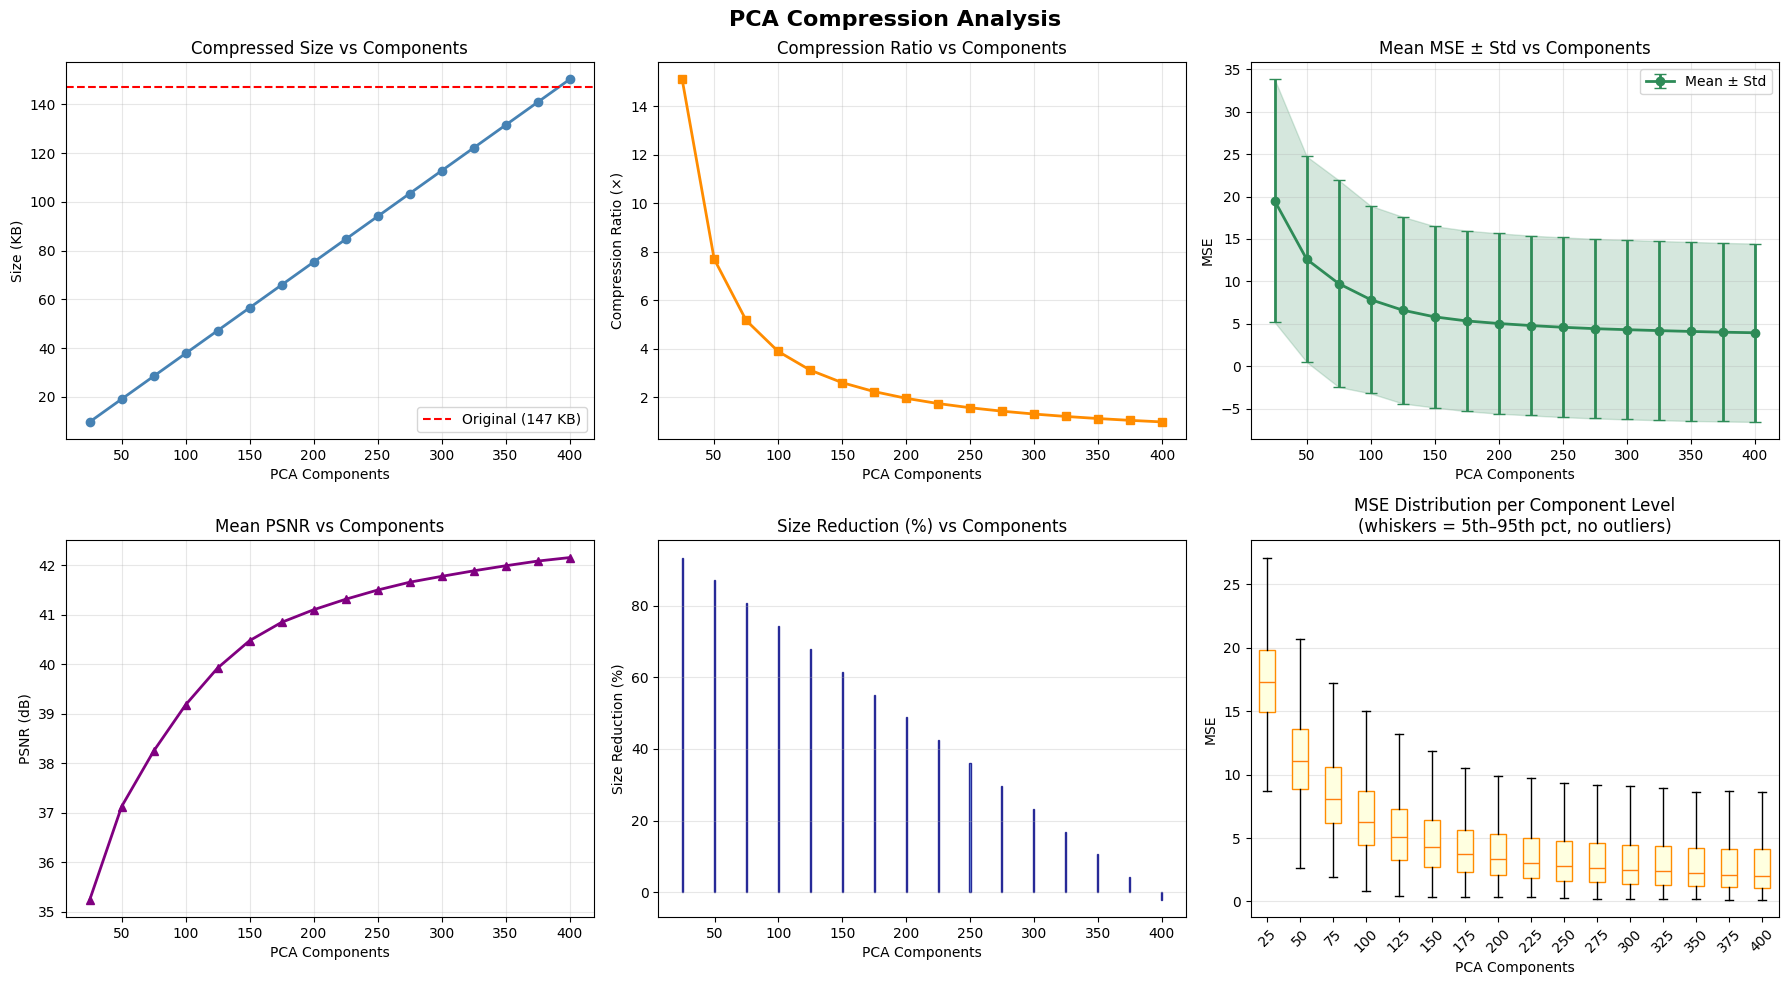

Figure saved as compression_analysis.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('PCA Compression Analysis', fontsize=16, fontweight='bold')

component_levels = sorted(df_comp['components'].unique())
x = np.array(component_levels)

# ── Plot 1: Mean size (KB) vs components ──────────────────────────────────────
ax = axes[0, 0]
ax.plot(x, size_stats['mean_KB'], marker='o', color='steelblue', linewidth=2)
ax.axhline(original_size / 1024, color='red', linestyle='--', label=f'Original ({original_size/1024:.0f} KB)')
ax.set_xlabel('PCA Components')
ax.set_ylabel('Size (KB)')
ax.set_title('Compressed Size vs Components')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 2: Compression ratio vs components ───────────────────────────────────
ax = axes[0, 1]
ax.plot(x, size_stats['compression_ratio'], marker='s', color='darkorange', linewidth=2)
ax.set_xlabel('PCA Components')
ax.set_ylabel('Compression Ratio (×)')
ax.set_title('Compression Ratio vs Components')
ax.grid(True, alpha=0.3)

# ── Plot 3: Mean MSE ± 1 std vs components ────────────────────────────────────
ax = axes[0, 2]
ax.errorbar(x, mse_stats['mean'], yerr=mse_stats['std'],
            fmt='o-', color='seagreen', linewidth=2, capsize=4, label='Mean ± Std')
ax.fill_between(x,
                mse_stats['mean'] - mse_stats['std'],
                mse_stats['mean'] + mse_stats['std'],
                alpha=0.2, color='seagreen')
ax.set_xlabel('PCA Components')
ax.set_ylabel('MSE')
ax.set_title('Mean MSE ± Std vs Components')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 4: PSNR vs components ────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(x, summary['psnr_mean_dB'], marker='^', color='purple', linewidth=2)
ax.set_xlabel('PCA Components')
ax.set_ylabel('PSNR (dB)')
ax.set_title('Mean PSNR vs Components')
ax.grid(True, alpha=0.3)

# ── Plot 5: Size reduction % vs components ────────────────────────────────────
ax = axes[1, 1]
ax.bar(x, size_stats['size_reduction_pct'], color='cornflowerblue', edgecolor='navy', alpha=0.8)
ax.set_xlabel('PCA Components')
ax.set_ylabel('Size Reduction (%)')
ax.set_title('Size Reduction (%) vs Components')
ax.grid(True, alpha=0.3, axis='y')

# ── Plot 6: MSE distribution (box) across component levels ───────────────────
ax = axes[1, 2]
data_to_plot = [df_comp[df_comp['components'] == c]['mse'].values for c in component_levels]
bp = ax.boxplot(data_to_plot, tick_labels=component_levels, showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightyellow')
    patch.set_edgecolor('darkorange')
ax.set_xlabel('PCA Components')
ax.set_ylabel('MSE')
ax.set_title('MSE Distribution per Component Level\n(whiskers = 5th–95th pct, no outliers)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('compression_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as compression_analysis.png")

## 7. Correlation & Rate–Distortion

=== Correlation: pca_size_bytes vs MSE ===
  Pearson  r = -0.2669  (p = 1.72e-287)
  Spearman ρ = -0.6049  (p = 0.00e+00)


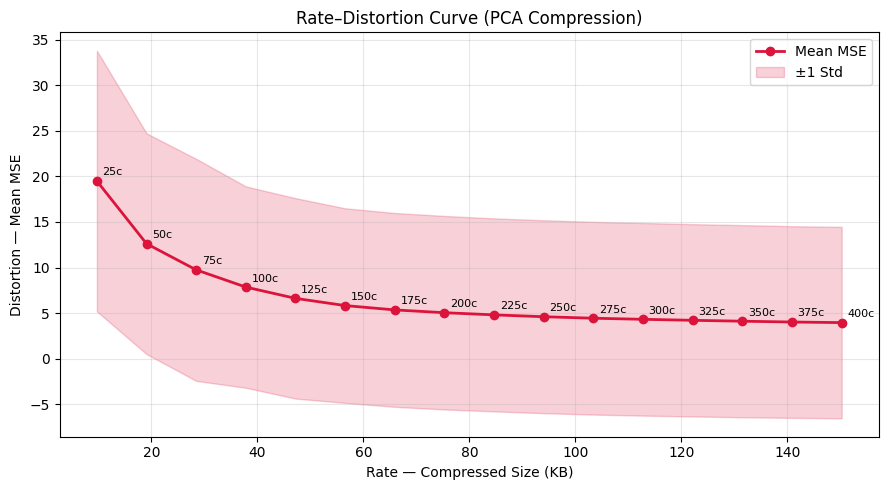

Rate–distortion figure saved.

=== Correlation matrix (compressed entries) ===


,components,mse,pca_size_bytes,compression_ratio,size_reduction_pct
components,1.000,-0.605,1.000,-1.000,-1.000
mse,-0.605,1.000,-0.605,0.605,0.605
pca_size_bytes,1.000,-0.605,1.000,-1.000,-1.000
compression_ratio,-1.000,0.605,-1.000,1.000,1.000
size_reduction_pct,-1.000,0.605,-1.000,1.000,1.000


In [11]:
from scipy import stats as sp_stats

# Pearson correlation between pca_size_bytes and MSE (across all compressed entries)
r_pearson, p_pearson = sp_stats.pearsonr(df_comp['pca_size_bytes'], df_comp['mse'])
r_spearman, p_spearman = sp_stats.spearmanr(df_comp['pca_size_bytes'], df_comp['mse'])

print("=== Correlation: pca_size_bytes vs MSE ===")
print(f"  Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.2e})")
print(f"  Spearman ρ = {r_spearman:.4f}  (p = {p_spearman:.2e})")

# ── Rate–Distortion curve (mean values per component level) ──────────────────
fig, ax = plt.subplots(figsize=(9, 5))
rd = summary.sort_values('mean_KB')
ax.plot(rd['mean_KB'], rd['mse_mean'], marker='o', linewidth=2, color='crimson', label='Mean MSE')
ax.fill_between(rd['mean_KB'],
                rd['mse_mean'] - rd['mse_std'],
                rd['mse_mean'] + rd['mse_std'],
                alpha=0.2, color='crimson', label='±1 Std')

for _, r in rd.iterrows():
    ax.annotate(f"{int(r.components)}c",
                xy=(r.mean_KB, r.mse_mean),
                xytext=(4, 4), textcoords='offset points', fontsize=8)

ax.set_xlabel('Rate — Compressed Size (KB)')
ax.set_ylabel('Distortion — Mean MSE')
ax.set_title('Rate–Distortion Curve (PCA Compression)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rate_distortion_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Rate–distortion figure saved.")

# ── Full numeric correlation matrix ──────────────────────────────────────────
print("\n=== Correlation matrix (compressed entries) ===")
display(df_comp[['components', 'mse', 'pca_size_bytes', 'compression_ratio', 'size_reduction_pct']]
        .corr(method='spearman').round(3))

## 8. Component Budget for a Target Size

Empirical bytes per component : 385.02  (0.3760 KB/component)
Target size                   : 60 KB  (61,440 bytes)
Max components within budget  : 159
Estimated size at 159 components : 59.8 KB

All existing component levels that fit within 60 KB:
  Components  Size (KB)    Ratio    MSE mean   PSNR (dB)
--------------------------------------------------------
          25        9.7   15.10x       19.49       35.23
          50       19.1    7.70x       12.61       37.12
          75       28.5    5.16x        9.75       38.24
         100       37.8    3.89x        7.86       39.18
         125       47.2    3.11x        6.62       39.92
         150       56.6    2.60x        5.83       40.47

→ 6 of 16 tested levels (25–400) fit within 60 KB.
→ You can extend up to ~159 components before exceeding 60 KB.

Projected quality at 159 components (power-law extrapolation):
  Estimated MSE  ≈ 6.2
  Estimated PSNR ≈ 40.23 dB


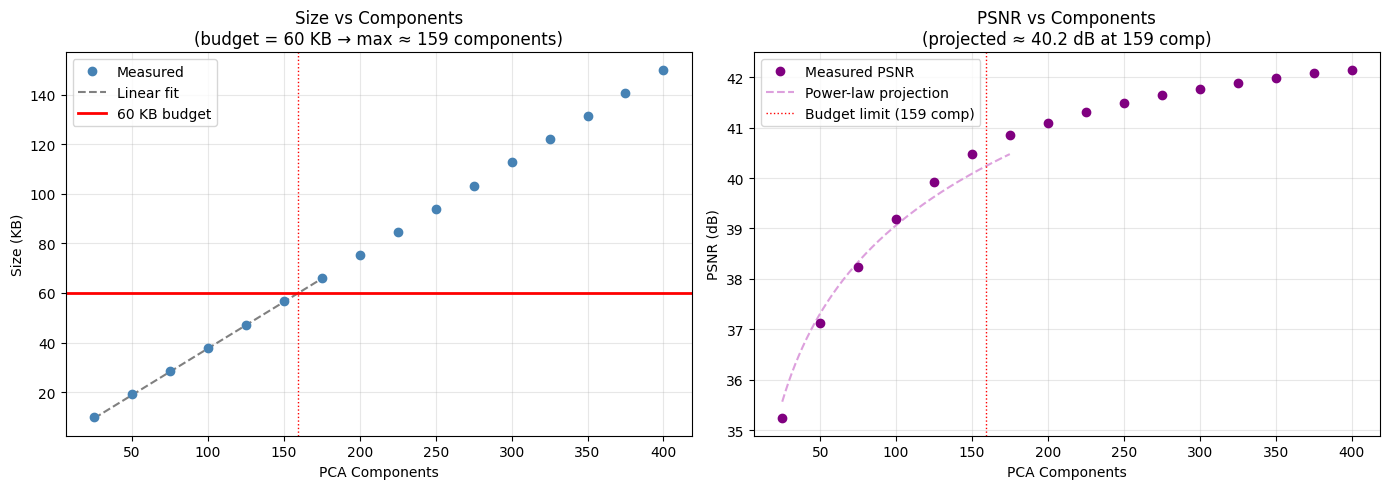

In [12]:
TARGET_SIZE_KB = 60
target_bytes = TARGET_SIZE_KB * 1024

# --- Fit bytes-per-component ratio from the data (size = k * components, no intercept) ---
comps = size_stats['components'].values
sizes = size_stats['mean'].values          # bytes

# Forced-through-origin linear fit: size = bytes_per_component * components
bytes_per_comp = np.dot(sizes, comps) / np.dot(comps, comps)
max_components = int(target_bytes / bytes_per_comp)

print(f"Empirical bytes per component : {bytes_per_comp:.2f}  ({bytes_per_comp/1024:.4f} KB/component)")
print(f"Target size                   : {TARGET_SIZE_KB} KB  ({target_bytes:,} bytes)")
print(f"Max components within budget  : {max_components}")
print(f"Estimated size at {max_components} components : {max_components * bytes_per_comp / 1024:.1f} KB")
print()

# --- Show all tested levels that fit within the budget ---
fits = size_stats[size_stats['mean'] <= target_bytes].copy()
fits = fits.merge(summary[['components', 'mse_mean', 'psnr_mean_dB']], on='components')
comp_range = f"{int(comps.min())}–{int(comps.max())}"
print(f"All existing component levels that fit within {TARGET_SIZE_KB} KB:")
print(f"{'Components':>12}  {'Size (KB)':>9}  {'Ratio':>7}  {'MSE mean':>10}  {'PSNR (dB)':>10}")
print("-" * 56)
for _, r in fits.sort_values('components').iterrows():
    print(f"{int(r.components):>12}  {r.mean_KB:>9.1f}  {r.compression_ratio:>6.2f}x  "
          f"{r.mse_mean:>10.2f}  {r.psnr_mean_dB:>10.2f}")

print(f"\n→ {len(fits)} of {len(size_stats)} tested levels ({comp_range}) fit within {TARGET_SIZE_KB} KB.")
print(f"→ You can extend up to ~{max_components} components before exceeding {TARGET_SIZE_KB} KB.")

# --- Extrapolated quality at max_components ---
# Fit MSE vs components with power law: MSE = a * components^b
log_mse = np.log(mse_stats['mean'].values)
slope, intercept = np.polyfit(np.log(comps), log_mse, 1)
projected_mse = np.exp(intercept) * max_components ** slope
projected_psnr = 10 * np.log10(255**2 / projected_mse)

print(f"\nProjected quality at {max_components} components (power-law extrapolation):")
print(f"  Estimated MSE  ≈ {projected_mse:.1f}")
print(f"  Estimated PSNR ≈ {projected_psnr:.2f} dB")

# --- Plot: size vs components with budget line ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

c_range = np.linspace(comps.min(), max_components * 1.1, 300)
ax1.plot(comps, sizes / 1024, 'o', color='steelblue', label='Measured', zorder=5)
ax1.plot(c_range, c_range * bytes_per_comp / 1024, '--', color='gray', label='Linear fit')
ax1.axhline(TARGET_SIZE_KB, color='red', linewidth=2, label=f'{TARGET_SIZE_KB} KB budget')
ax1.axvline(max_components, color='red', linewidth=1, linestyle=':')
ax1.set_xlabel('PCA Components')
ax1.set_ylabel('Size (KB)')
ax1.set_title(f'Size vs Components\n(budget = {TARGET_SIZE_KB} KB → max ≈ {max_components} components)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PSNR projection
c_proj = np.linspace(comps.min(), max_components * 1.1, 300)
mse_proj = np.exp(intercept) * c_proj ** slope
psnr_proj = 10 * np.log10(255**2 / mse_proj)

ax2.plot(comps, [10 * np.log10(255**2 / m) for m in mse_stats['mean']], 'o',
         color='purple', label='Measured PSNR', zorder=5)
ax2.plot(c_proj, psnr_proj, '--', color='plum', label='Power-law projection')
ax2.axvline(max_components, color='red', linewidth=1, linestyle=':',
            label=f'Budget limit ({max_components} comp)')
ax2.set_xlabel('PCA Components')
ax2.set_ylabel('PSNR (dB)')
ax2.set_title(f'PSNR vs Components\n(projected ≈ {projected_psnr:.1f} dB at {max_components} comp)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('component_budget_analysis.png', dpi=150, bbox_inches='tight')
plt.show()